In [5]:
!pip install fiftyone

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.7/17.7 MB 39.9 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 323.5/323.5 kB 7.9 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.9/112.9 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.5/112.5 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.8/74.8 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 58.5 MB/s eta 0:00:0000:0100:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.6/101.6 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.

In [ ]:
import os
import json
import cv2
import glob
import random
import joblib
import numpy as np
import fiftyone as fo
import fiftyone.zoo as foz
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from skimage.feature import hog
from skimage import exposure
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report
from dataclasses import dataclass


In [1]:
# --- Path to dataset & label ---
BASE_DIR = '/kaggle/input/datasets/editcadic/bd128-large/bdd_cropped_data (2)/'
JSON_TRAIN_PATH = '/kaggle/input/datasets/marquis03/bdd100k/train/annotations/bdd100k_labels_images_train.json' 
IMAGE_TRAIN_DIR = '/kaggle/input/datasets/marquis03/bdd100k/train/images'
JSON_VAL_PATH = '/kaggle/input/datasets/marquis03/bdd100k/val/annotations/bdd100k_labels_images_val.json' 
IMAGE_VAL_DIR = '/kaggle/input/datasets/marquis03/bdd100k/val/images'


# Save output dir
OUTPUT_DIR = '/kaggle/working/data_multiclass/'

# All classes in dataset 
CLASSES = ['car', 'bus', 'truck', 'motorcycle', 'background']
TARGET_SIZE = (128, 128)
ORIENTATIONS = 9
PIXELS_PER_CELL = (8, 8)
CELLS_PER_BLOCK = (2, 2)


In [4]:

# check if the croped background overlaps with the vehicle
def is_overlap(box1, box2):
    x1_min, y1_min, x1_max, y1_max = box1
    x2_min, y2_min, x2_max, y2_max = box2
    return not (x1_max < x2_min or x2_max < x1_min or y1_max < y2_min or y2_max < y1_min)

# Function use to crop base dataset into multiclass dataset
def process_multiclass(json_path, image_dir, split_name, max_images_to_scan):
    print(f"\n--- Đang xử lý tập {split_name.upper()} ---")
    
    MAX_SAMPLES = 6000 if split_name == 'train' else 1000 
    
    for cls in CLASSES:
        os.makedirs(os.path.join(OUTPUT_DIR, split_name, cls), exist_ok=True)

    with open(json_path, 'r') as f:
        data = json.load(f)
    
    counts = {cls: 0 for cls in CLASSES}
    
    for i, item in enumerate(data[:max_images_to_scan]):
        
        if all(count >= MAX_SAMPLES for count in counts.values()):
            print("Đã thu thập đủ số lượng cân bằng cho TẤT CẢ các lớp. Dừng quét sớm!")
            break

        img_path = os.path.join(image_dir, item['name'])
        if not os.path.exists(img_path): continue
        image = cv2.imread(img_path)
        if image is None: continue
        
        h_orig, w_orig = image.shape[:2]
        all_boxes = []

        if 'labels' in item:
            for label in item['labels']:
                if 'box2d' not in label: continue
                category = label['category']
                
                if category in CLASSES:
                    if category == 'motorcycle':
                        continue
                    elif category in CLASSES:
                        if counts[category] >= MAX_SAMPLES:
                            continue
                        
                    box = label['box2d']
                    x1, y1, x2, y2 = int(box['x1']), int(box['y1']), int(box['x2']), int(box['y2'])
                    all_boxes.append((x1, y1, x2, y2))
                    
                    w, h = (x2 - x1), (y2 - y1)
                    if w < 50 or h < 50:
                        continue
                    
                    crop = image[max(0,y1):min(h_orig,y2), max(0,x1):min(w_orig,x2)]
                    if crop.size > 0:
                        resized = cv2.resize(crop, TARGET_SIZE)
                        save_path = os.path.join(OUTPUT_DIR, split_name, category, f"{category}_{counts[category]}.jpg")
                        cv2.imwrite(save_path, resized)
                        counts[category] += 1

        if counts['background'] < 50000:
            for _ in range(3):
                if counts['background'] >= 50000: break
                w, h = random.randint(64, 256), random.randint(64, 256)
                x1, y1 = random.randint(0, max(1, w_orig - w - 1)), random.randint(0, max(1, h_orig - h - 1))
                rand_box = (x1, y1, x1 + w, y1 + h)
                
                if not any(is_overlap(rand_box, b) for b in all_boxes):
                    crop = image[y1:y1+h, x1:x1+w]
                    if crop.size > 0:
                        resized = cv2.resize(crop, TARGET_SIZE)
                        save_path = os.path.join(OUTPUT_DIR, split_name, 'background', f"bg_{counts['background']}.jpg")
                        cv2.imwrite(save_path, resized)
                        counts['background'] += 1

        if (i + 1) % 1000 == 0:
            print(f"Đã duyệt {i+1} ảnh. Thống kê hiện tại: {counts}")

    print(f"Hoàn thành {split_name}. Tổng kết: {counts}")


--- Đang xử lý tập TRAIN ---
Đã duyệt 1000 ảnh. Thống kê hiện tại: {'car': 3171, 'bus': 98, 'truck': 275, 'motorcycle': 0, 'background': 1821}
Đã duyệt 2000 ảnh. Thống kê hiện tại: {'car': 6000, 'bus': 184, 'truck': 545, 'motorcycle': 0, 'background': 3800}
Đã duyệt 3000 ảnh. Thống kê hiện tại: {'car': 6000, 'bus': 307, 'truck': 788, 'motorcycle': 0, 'background': 6599}
Đã duyệt 4000 ảnh. Thống kê hiện tại: {'car': 6000, 'bus': 393, 'truck': 1032, 'motorcycle': 0, 'background': 9429}
Đã duyệt 5000 ảnh. Thống kê hiện tại: {'car': 6000, 'bus': 504, 'truck': 1289, 'motorcycle': 0, 'background': 12251}
Đã duyệt 6000 ảnh. Thống kê hiện tại: {'car': 6000, 'bus': 608, 'truck': 1534, 'motorcycle': 0, 'background': 15076}
Đã duyệt 7000 ảnh. Thống kê hiện tại: {'car': 6000, 'bus': 709, 'truck': 1783, 'motorcycle': 0, 'background': 17904}
Đã duyệt 8000 ảnh. Thống kê hiện tại: {'car': 6000, 'bus': 809, 'truck': 2061, 'motorcycle': 0, 'background': 20732}
Đã duyệt 9000 ảnh. Thống kê hiện tại: {'ca

In [ ]:

process_multiclass(JSON_TRAIN_PATH, IMAGE_TRAIN_DIR, 'train', 70000)
process_multiclass(JSON_VAL_PATH, IMAGE_VAL_DIR, 'val', 10000)

In [7]:
def crop_coo_image(target_samples, target_size, output_dir):
    count = 0
    for sample in dataset:
        if count >= target_samples:
            break
            
        img_path = sample.filepath
        image = cv2.imread(img_path)
        if image is None: continue
        h_orig, w_orig = image.shape[:2]
        
        if sample.ground_truth is None: continue
        
        for detection in sample.ground_truth.detections:
            if detection.label == 'motorcycle':
                box = detection.bounding_box
                x_min = int(box[0] * w_orig)
                y_min = int(box[1] * h_orig)
                box_w = int(box[2] * w_orig)
                box_h = int(box[3] * h_orig)
                x_max = x_min + box_w
                y_max = y_min + box_h
                
                # Lọc bỏ xe quá nhỏ
                if box_w < 40 or box_h < 40:
                    continue
                    
                crop = image[max(0, y_min):min(h_orig, y_max), max(0, x_min):min(w_orig, x_max)]
                
                if crop.size > 0:
                    resized = cv2.resize(crop, target_size)
                    save_path = os.path.join(output_dir, f"coco_moto_val_{count}.jpg")
                    cv2.imwrite(save_path, resized)
                    count += 1
                    
                    if count >= target_samples:
                        break
    print(f"Tuyệt vời! Đã bổ sung thành công {count} ảnh Xe máy chuẩn 64x64 vào thư mục.")

In [8]:

# --- 1. CẤU HÌNH ---
OUTPUT_MOTOCYCLE_TRAIN_DIR = '/kaggle/working/data_multiclass/train/motorcycle/'
os.makedirs(OUTPUT_MOTOCYCLE_TRAIN_DIR, exist_ok=True)

print("Đang kết nối đến COCO Dataset và tải dữ liệu Xe máy...")
# --- 2. TẢI DỮ LIỆU TỪ COCO ---
dataset = foz.load_zoo_dataset(
    "coco-2017",
    split="train",
    classes=["motorcycle"],
    max_samples=6000,
)

print(f"Đã tải xong {len(dataset)} ảnh chứa xe máy. Tiến hành cắt...")

# --- 3. CẮT VÀ LƯU DỮ LIỆU ---
crop_coo_image(target_samples=6000, target_size=TARGET_SIZE, output_dir=OUTPUT_MOTOCYCLE_TRAIN_DIR)

/usr/local/lib/python3.12/dist-packages/glob2/fnmatch.py:141: SyntaxWarning: invalid escape sequence '\Z'
  return '(?ms)' + res + '\Z'


Đang kết nối đến COCO Dataset và tải dữ liệu Xe máy...
 100% |██████|    1.9Gb/1.9Gb [14.7s elapsed, 0s remaining, 156.8Mb/s]      
Extracting annotations to '/root/fiftyone/coco-2017/raw/instances_train2017.json'
Only found 3502 (<6000) samples matching your requirements
 100% |████████████████| 3502/3502 [16.6m elapsed, 0s remaining, 3.6 images/s]      
Writing annotations for 3502 downloaded samples to '/root/fiftyone/coco-2017/train/labels.json'
Dataset info written to '/root/fiftyone/coco-2017/info.json'
Loading 'coco-2017' split 'train'
 100% |███████████████| 3502/3502 [30.9s elapsed, 0s remaining, 108.2 samples/s]      
Dataset 'coco-2017-train-6000' created
Đã tải xong 3502 ảnh chứa xe máy. Tiến hành cắt...
Tuyệt vời! Đã bổ sung thành công 6000 ảnh Xe máy chuẩn 64x64 vào thư mục.


In [9]:

OUTPUT_MOTOCYCLE_VAL_DIR = '/kaggle/working/data_multiclass/val/motorcycle/' # Đổi sang thư mục val
os.makedirs(OUTPUT_MOTOCYCLE_VAL_DIR, exist_ok=True)

print("Đang kết nối COCO Dataset để tải dữ liệu Xe máy (Tập Validation)...")

dataset = foz.load_zoo_dataset(
    "coco-2017",
    split="validation",
    classes=["motorcycle"],
    max_samples=1000,
)

print(f"Đã tải xong {len(dataset)} ảnh. Tiến hành cắt...")

# --- 3. CẮT VÀ LƯU DỮ LIỆU ---
crop_coo_image(target_samples=1000, target_size=TARGET_SIZE, output_dir=OUTPUT_MOTOCYCLE_VAL_DIR)

Đang kết nối COCO Dataset để tải dữ liệu Xe máy (Tập Validation)...
Found annotations at '/root/fiftyone/coco-2017/raw/instances_val2017.json'
Only found 159 (<10000) samples matching your requirements
 100% |██████████████████| 159/159 [45.3s elapsed, 0s remaining, 3.6 images/s]      
Writing annotations for 159 downloaded samples to '/root/fiftyone/coco-2017/validation/labels.json'
Dataset info written to '/root/fiftyone/coco-2017/info.json'
Loading 'coco-2017' split 'validation'
 100% |█████████████████| 159/159 [1.4s elapsed, 0s remaining, 115.4 samples/s]         
Dataset 'coco-2017-validation-10000' created
Đã tải xong 159 ảnh. Tiến hành cắt...
Tuyệt vời! Đã bổ sung thành công 264 ảnh Xe máy chuẩn 64x64 vào thư mục.


In [ ]:
import shutil
import os

print("Đang nén dữ liệu... Vui lòng đợi vài phút.")
shutil.make_archive('/kaggle/working/bdd_cropped_data', 'zip', '/kaggle/working/data_multiclass')
print("Nén thành công! Kích thước file:")
print(os.path.getsize('/kaggle/working/bdd_cropped_data.zip') / (1024 * 1024), "MB")

In [2]:
MOTOCYCLE_DIR_PATH = '/kaggle/input/datasets/editcadic/bd128-large/bdd_cropped_data (2)/train/motorcycle'

all_images = [f for f in os.listdir(MOTOCYCLE_DIR_PATH) if f.endswith('.jpg')]

if len(all_images) == 0:
    print("Thư mục trống! Có vẻ như quá trình tải dữ liệu trước đó chưa thành công.")
else:
    num_samples = 5
    sample_images = random.sample(all_images, min(num_samples, len(all_images)))

    fig, axes = plt.subplots(1, num_samples, figsize=(15, 3))
    
    if num_samples == 1:
        axes = [axes]

    print(f"Hiển thị ngẫu nhiên {len(sample_images)} ảnh mẫu (Kích thước đã chuẩn hóa 64x64):")

    for i, img_name in enumerate(sample_images):
        img_path = os.path.join(MOTOCYCLE_DIR_PATH, img_name)
        
        img = cv2.imread(img_path)
        
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        axes[i].imshow(img_rgb)
        axes[i].set_title(img_name, fontsize=10)
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/input/datasets/editcadic/bd128-large/bdd_cropped_data (2)/train/motorcycle'

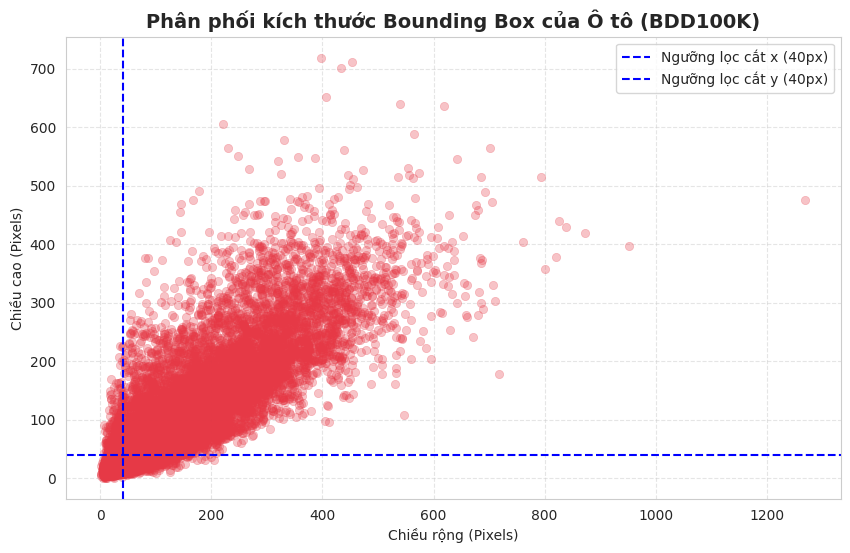

In [6]:
import json
import matplotlib.pyplot as plt


with open(JSON_TRAIN_PATH, 'r') as f:
    data = json.load(f)

widths, heights = [], []
for item in data[:5000]: # Lấy mẫu 5000 ảnh đầu tiên cho nhanh
    if 'labels' in item:
        for label in item['labels']:
            if label['category'] == 'car' and 'box2d' in label:
                box = label['box2d']
                widths.append(float(box['x2']) - float(box['x1']))
                heights.append(float(box['y2']) - float(box['y1']))

plt.figure(figsize=(10, 6))
sns.scatterplot(x=widths, y=heights, alpha=0.3, color='#e63946', edgecolor=None)
plt.axvline(x=40, color='blue', linestyle='--', label='Ngưỡng lọc cắt x (40px)')
plt.axhline(y=40, color='blue', linestyle='--', label='Ngưỡng lọc cắt y (40px)')

plt.title('Phân phối kích thước Bounding Box của Ô tô (BDD100K)', fontsize=14, fontweight='bold')
plt.xlabel('Chiều rộng (Pixels)')
plt.ylabel('Chiều cao (Pixels)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Đang đọc file JSON và trích xuất kích thước...
Đã trích xuất thành công 54400 Bounding Boxes.


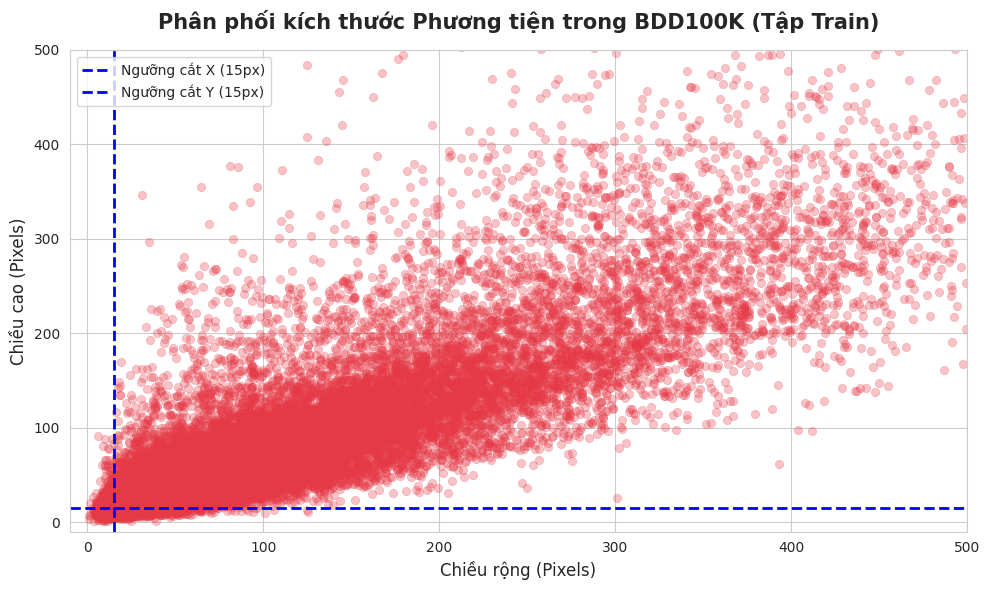

In [5]:
print("Đang đọc file JSON và trích xuất kích thước...")
with open(JSON_TRAIN_PATH, 'r') as f:
    data = json.load(f)

widths = []
heights = []

for item in data[:5000]:
    if 'labels' in item:
        for label in item['labels']:
            if label['category'] in ['car', 'bus', 'truck']:
                if 'box2d' in label:
                    box = label['box2d']
                    w = float(box['x2']) - float(box['x1'])
                    h = float(box['y2']) - float(box['y1'])
                    widths.append(w)
                    heights.append(h)

print(f"Đã trích xuất thành công {len(widths)} Bounding Boxes.")

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

sns.scatterplot(x=widths, y=heights, color='#e63946', alpha=0.3, edgecolor=None)

plt.axvline(x=50, color='blue', linestyle='--', linewidth=2, label='Ngưỡng cắt X (50px)')
plt.axhline(y=50, color='blue', linestyle='--', linewidth=2, label='Ngưỡng cắt Y (50px)')

plt.title('Phân phối kích thước Phương tiện trong BDD100K (Tập Train)', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Chiều rộng (Pixels)', fontsize=12)
plt.ylabel('Chiều cao (Pixels)', fontsize=12)

plt.xlim(-10, 500)
plt.ylim(-10, 500)

plt.legend()
plt.tight_layout()

plt.savefig('bounding_box_scatter.png', dpi=300)
plt.show()

/tmp/ipykernel_57/2527269696.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Loại đối tượng', y='Số lượng mẫu', data=df, palette='rocket')


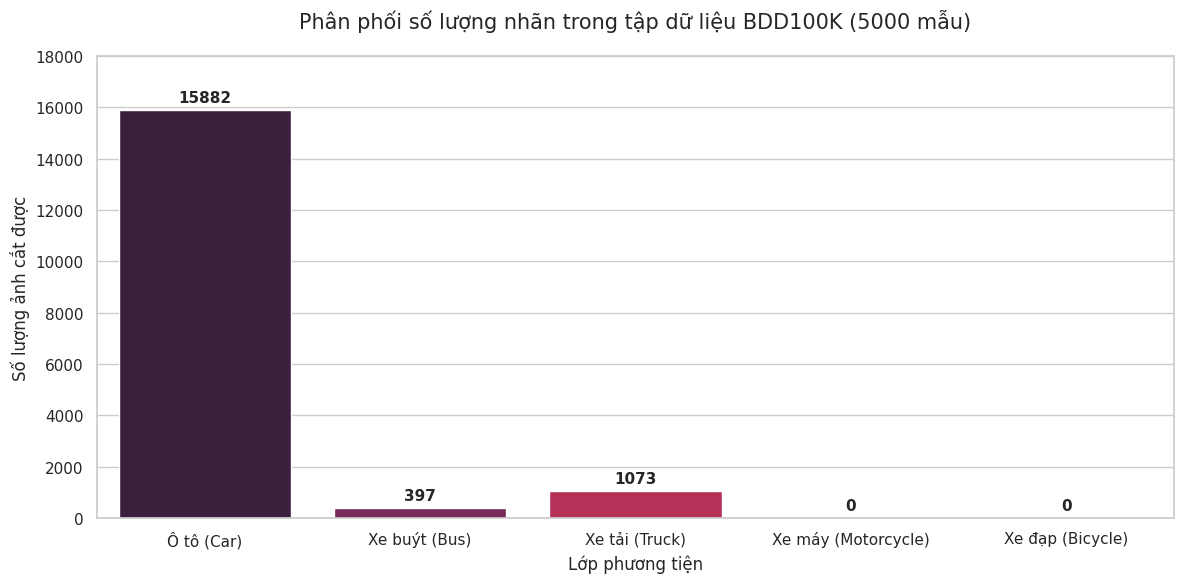

In [22]:
data = {
    'Loại đối tượng': ['Ô tô (Car)', 'Xe buýt (Bus)', 'Xe tải (Truck)', 'Xe máy (Motorcycle)', 'Xe đạp (Bicycle)'],
    'Số lượng mẫu': [15882, 397, 1073, 0, 0]
}

df = pd.DataFrame(data)

plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

ax = sns.barplot(x='Loại đối tượng', y='Số lượng mẫu', data=df, palette='rocket')

for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{int(height)}', 
                (p.get_x() + p.get_width() / 2., height), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points',
                fontsize=11, fontweight='bold')

plt.title('Phân phối số lượng nhãn trong tập dữ liệu BDD100K (5000 mẫu)', fontsize=15, pad=20)
plt.xlabel('Lớp phương tiện', fontsize=12)
plt.ylabel('Số lượng ảnh cắt được', fontsize=12)

plt.ylim(0, 18000)
plt.tight_layout()
plt.show()

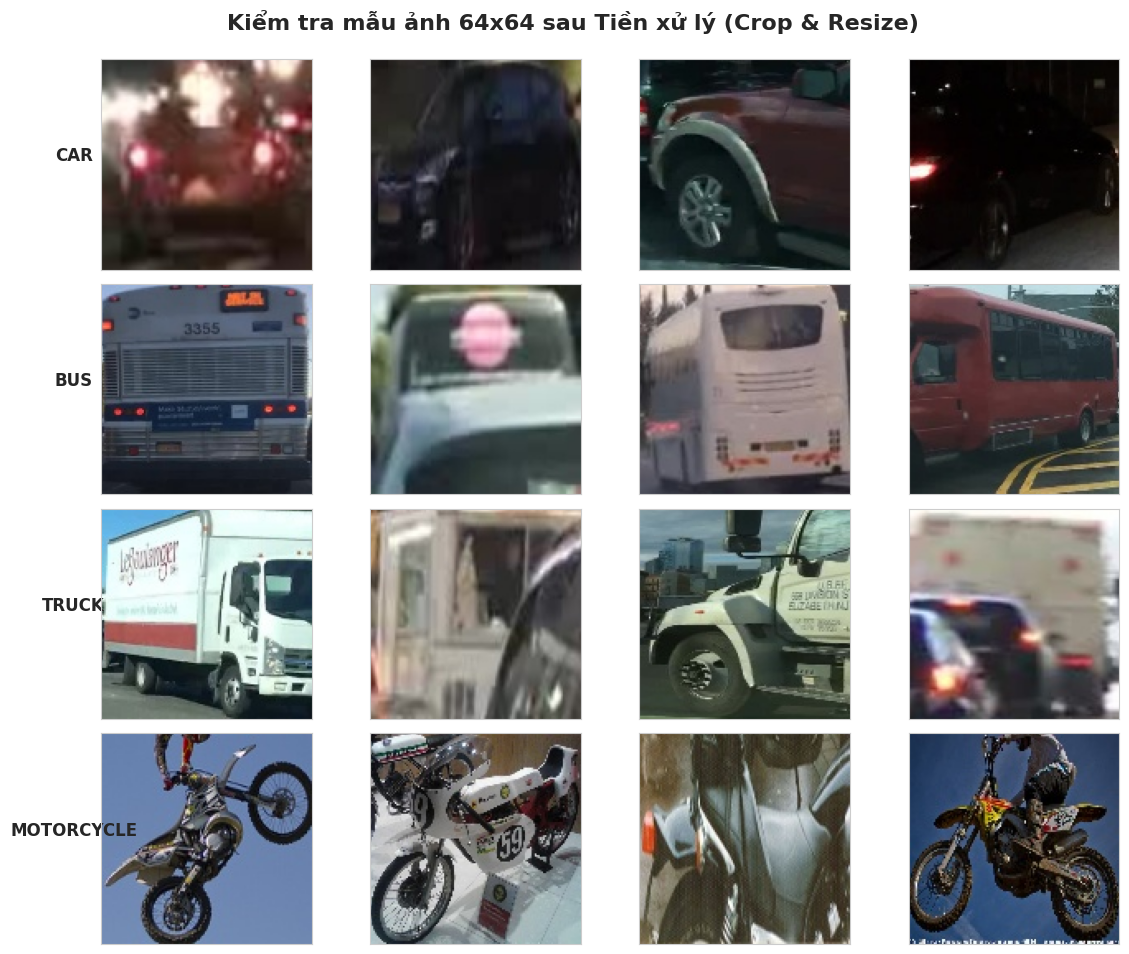

In [9]:
import os
import random
import cv2
import matplotlib.pyplot as plt

CLASSES_TO_SHOW = ['car', 'bus', 'truck', 'motorcycle']
NUM_SAMPLES_PER_CLASS = 4 

fig, axes = plt.subplots(len(CLASSES_TO_SHOW), NUM_SAMPLES_PER_CLASS, figsize=(12, 10))
fig.suptitle("Kiểm tra mẫu ảnh 64x64 sau Tiền xử lý (Crop & Resize)", fontsize=16, fontweight='bold', y=0.95)

for i, cls_name in enumerate(CLASSES_TO_SHOW):
    folder_path = os.path.join(BASE_DIR, f"train/{cls_name}")
    
    if not os.path.exists(folder_path):
        print(f"[WARNING] Thư mục không tồn tại: {folder_path}")
        continue
        
    all_images = [f for f in os.listdir(folder_path) if f.endswith('.jpg')]
    
    if len(all_images) == 0:
        print(f"[WARNING] Thư mục trống: {folder_path}")
        continue
        
    samples = random.sample(all_images, min(NUM_SAMPLES_PER_CLASS, len(all_images)))
    
    for j, img_name in enumerate(samples):
        img_path = os.path.join(folder_path, img_name)
        
        img = cv2.imread(img_path)
        
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        ax = axes[i, j]
        ax.imshow(img_rgb)
        
        if j == 0:
            ax.set_ylabel(cls_name.upper(), fontsize=12, fontweight='bold', rotation=0, labelpad=20)
            
        ax.set_xticks([])
        ax.set_yticks([])

plt.tight_layout()
plt.subplots_adjust(top=0.90)
plt.show()

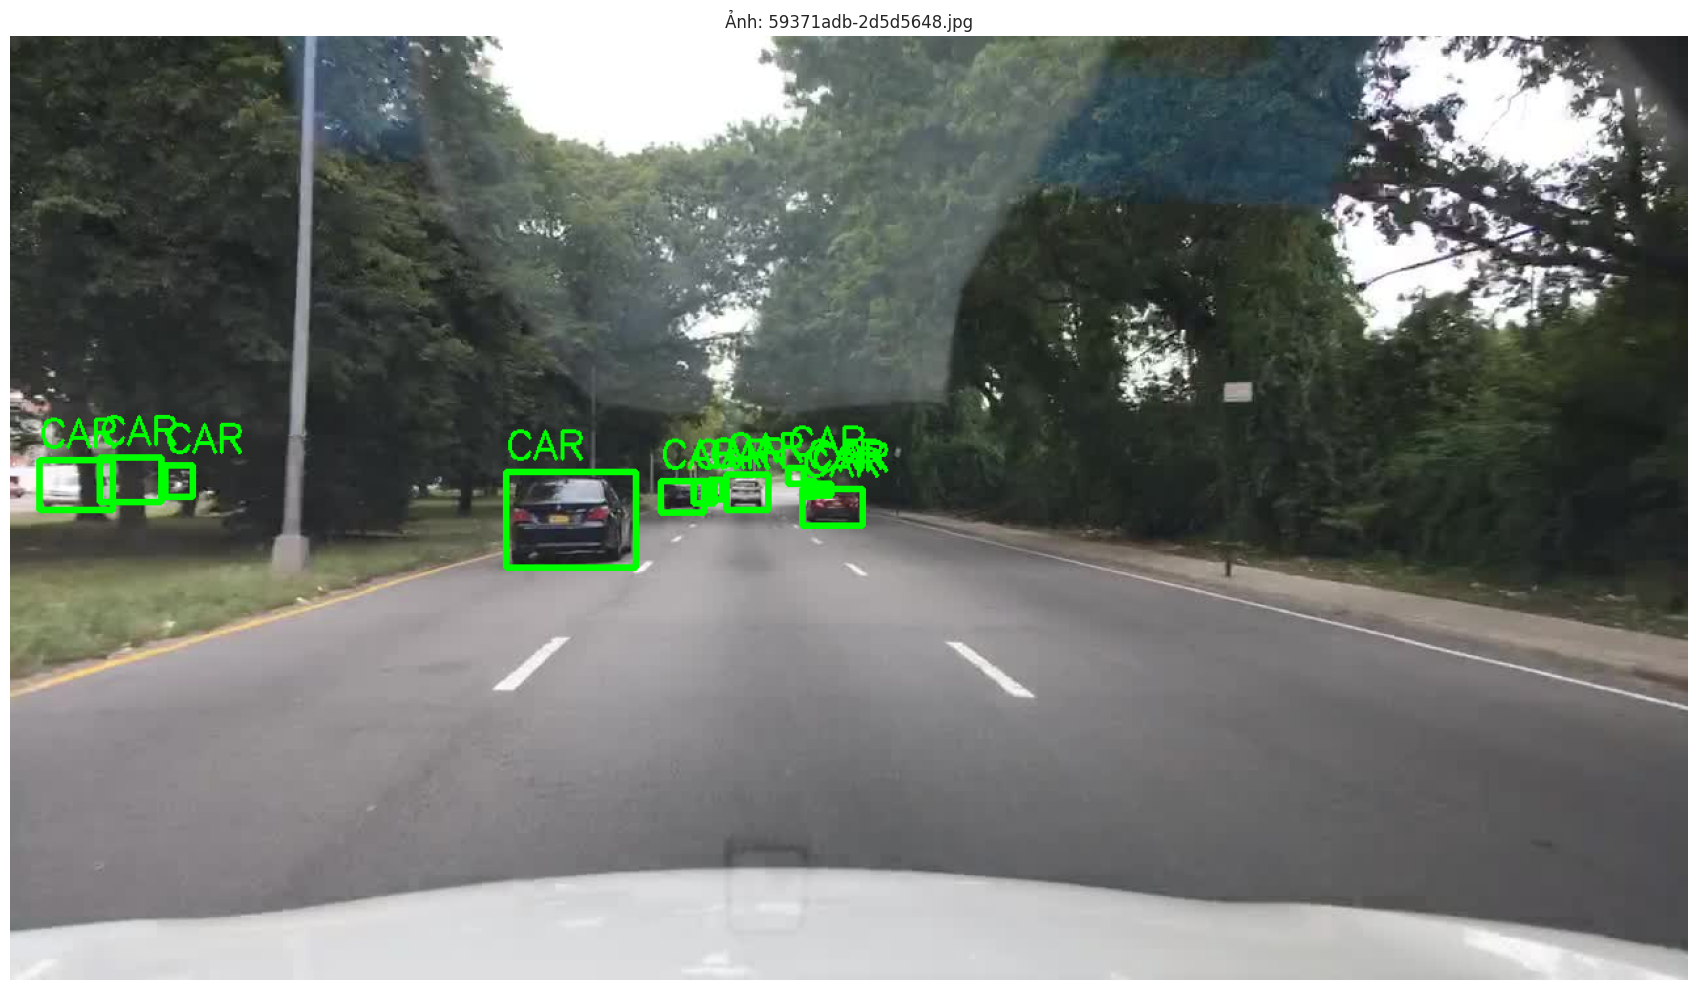

In [16]:
COLOR_MAP = {
    'car': (0, 255, 0), 
    'bus': (255, 0, 0),
    'truck': (0, 255, 255),
    'motorcycle': (255, 165, 0)
}

def draw_bboxes(num_samples=1):
    with open(JSON_TRAIN_PATH, 'r') as f:
        data = json.load(f)

    samples = random.sample(data, num_samples)
    
    fig, axes = plt.subplots(1, num_samples, figsize=(20, 10))

    axes = [axes]
    
    for i, item in enumerate(samples):
        img_path = os.path.join(IMAGE_TRAIN_DIR, item['name'])
        image = cv2.imread(img_path)
        if image is None: continue
        
        if 'labels' in item:
            for label in item['labels']:
                category = label['category']
                if category in COLOR_MAP and 'box2d' in label:
                    box = label['box2d']
                    x1, y1 = int(box['x1']), int(box['y1'])
                    x2, y2 = int(box['x2']), int(box['y2'])
                    
                    color = COLOR_MAP[category]
                    cv2.rectangle(image, (x1, y1), (x2, y2), color, 3)
                    
                    label_text = category.upper()
                    cv2.putText(image, label_text, (x1, y1 - 10), 
                                cv2.FONT_HERSHEY_SIMPLEX, 1, color, 2)

        image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        axes[i].imshow(image_rgb)
        axes[i].set_title(f"Ảnh: {item['name']}", fontsize=12)
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

# Thực hiện vẽ
draw_bboxes(num_samples=1)

FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/working/data_multiclass/train/car'

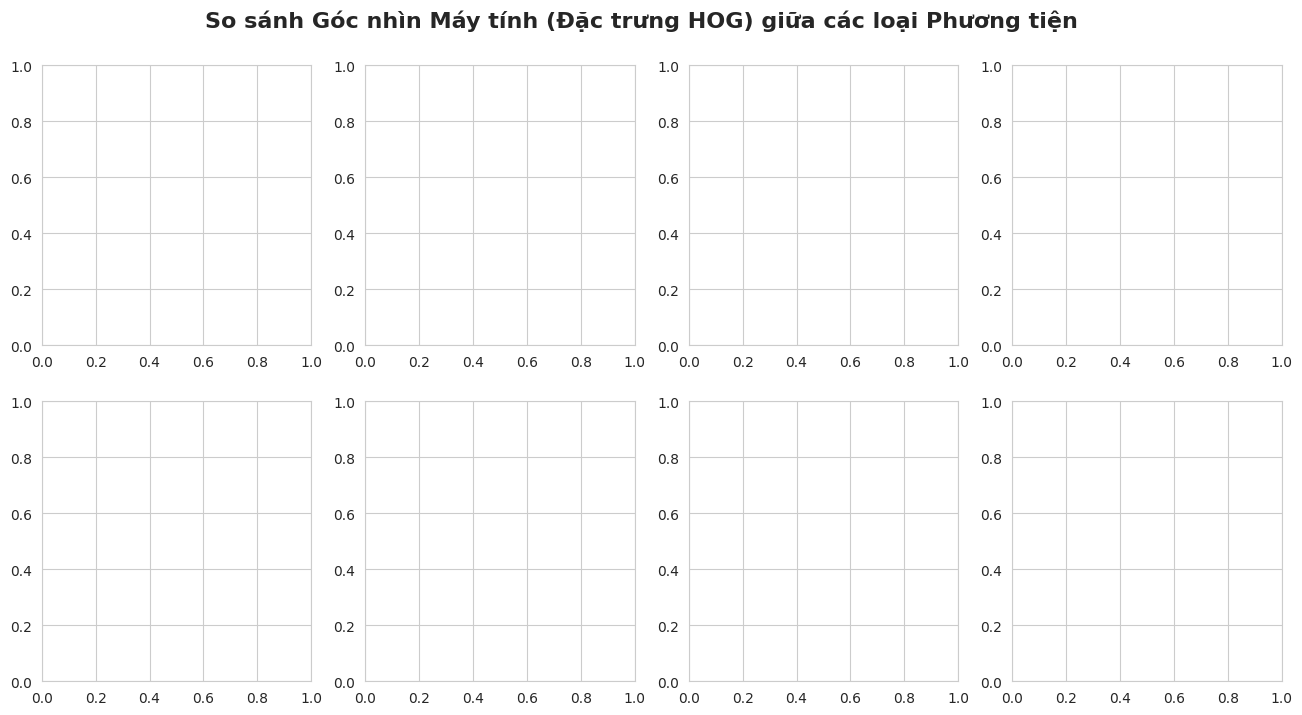

In [17]:
classes_to_compare = ['car', 'truck', 'bus', 'motorcycle']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle("So sánh Góc nhìn Máy tính (Đặc trưng HOG) giữa các loại Phương tiện", fontsize=16, fontweight='bold', y=0.95)

for i, cls in enumerate(classes_to_compare):
    folder_path = os.path.join(IMAGE_TRAIN_DIR, cls)
    images = [f for f in os.listdir(folder_path) if f.endswith('.jpg')]
    
    if len(images) > 0:
        img_name = random.choice(images)
        img_path = os.path.join(folder_path, img_name)
        img = cv2.imread(img_path)
        img = cv2.resize(img, TARGET_SIZE)
        
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[0, i].imshow(img_rgb)
        axes[0, i].set_title(f"Ảnh gốc: {cls.upper()}", fontsize=12)
        axes[0, i].axis('off')
        
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        
        fd, hog_image = hog(gray, orientations=ORIENTATIONS, pixels_per_cell=PIXELS_PER_CELL,
                            cells_per_block=CELLS_PER_BLOCK, block_norm='L2-Hys', visualize=True)
        
        hog_image_rescaled = exposure.rescale_intensity(hog_image, in_range=(0, 10))
        
        axes[1, i].imshow(hog_image_rescaled, cmap='gray')
        axes[1, i].set_title(f"Đặc trưng HOG", fontsize=12)
        axes[1, i].axis('off')

plt.tight_layout()
plt.subplots_adjust(top=0.88)
plt.show()

In [32]:
TRAIN_DIR = '/kaggle/input/datasets/editcadic/bd128-large/bdd_cropped_data (2)/train'
classes = ['car', 'bus', 'truck', 'motorcycle']
counts = [6000, 6000, 6000, 6000, 6000, 50000]

for cls in classes:
    folder_path = os.path.join(TRAIN_DIR, cls)
    if os.path.exists(folder_path):
        num_images = len([f for f in os.listdir(folder_path) if f.endswith('.jpg')])
        counts.append(num_images)
    else:
        counts.append(0)

display_names = ['Ô tô (Car)', 'Xe buýt (Bus)', 'Xe tải (Truck)', 'Xe máy (Moto)', 'Xe đạp (Bicycle))', 'Backgound']

plt.figure(figsize=(10, 5))
sns.set_theme(style="whitegrid")

ax = sns.barplot(x=display_names, y=counts, color='#2a9d8f')

for i, p in enumerate(ax.patches):
    ax.annotate(f'{counts[i]}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=12, fontweight='bold', color='#264653', xytext=(0, 5), textcoords='offset points')

plt.title('Hình 3.1: Phân phối Dữ liệu Tập Train sau khi Cân bằng (Undersampling & COCO)', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Số lượng mẫu (Samples)', fontsize=12)
plt.ylim(0, max(counts) + 200)
sns.despine(left=True, bottom=False)
plt.tight_layout()
plt.show()

ValueError: All arrays must be of the same length

<Figure size 1000x500 with 0 Axes>

FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/working/data_multiclass/train/car'

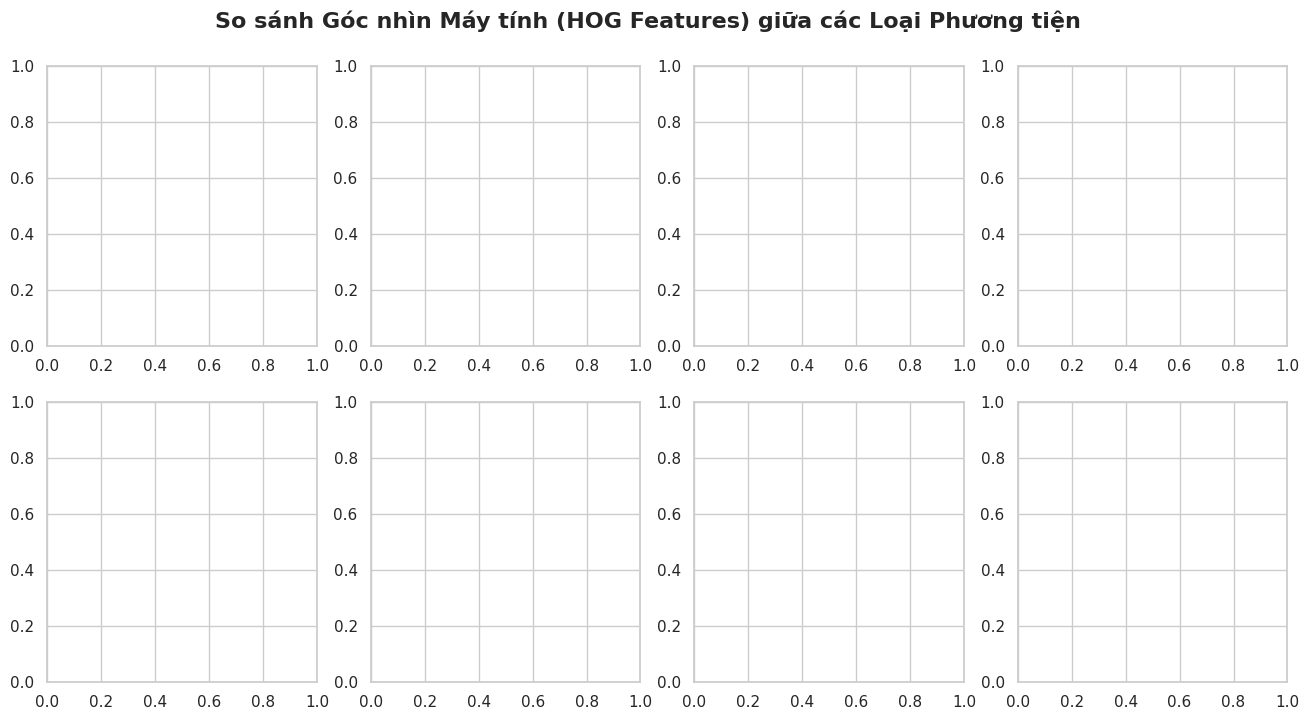

In [19]:

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle("So sánh Góc nhìn Máy tính (HOG Features) giữa các Loại Phương tiện", fontsize=16, fontweight='bold', y=0.95)

for i, cls in enumerate(classes):
    folder_path = os.path.join(TRAIN_DIR, cls)
    images = [f for f in os.listdir(folder_path) if f.endswith('.jpg')]
    
    if len(images) > 0:
        img_name = random.choice(images)
        img_path = os.path.join(folder_path, img_name)
        img = cv2.imread(img_path)
        img = cv2.resize(img, TARGET_SIZE)
        
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[0, i].imshow(img_rgb)
        axes[0, i].set_title(f"Ảnh gốc: {cls.upper()}", fontsize=12)
        axes[0, i].axis('off')
        
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        fd, hog_image = hog(gray, orientations=ORIENTATIONS, pixels_per_cell=PIXELS_PER_CELL,
                            cells_per_block=CELLS_PER_BLOCK, block_norm='L2-Hys', visualize=True)
        
        hog_image_rescaled = exposure.rescale_intensity(hog_image, in_range=(0, 10))
        
        axes[1, i].imshow(hog_image_rescaled, cmap='gray')
        axes[1, i].set_title(f"Đặc trưng HOG", fontsize=12)
        axes[1, i].axis('off')

plt.tight_layout()
plt.subplots_adjust(top=0.88)
plt.show()

In [ ]:
CLASSES = ['car', 'bus', 'truck', 'motorcycle', 'background']
DATA_DIR = BASE_DIR

def extract_hog_features(image_paths):
    features = []
    for path in image_paths:
        img = cv2.imread(path)
        if img is None: continue
        img = cv2.resize(img, IMAGE_SIZE)
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        hog_feature = hog(gray, orientations=ORIENTATIONS, pixels_per_cell=PIXELS_PER_CELL,
                          cells_per_block=CELLS_PER_BLOCK, block_norm='L2-Hys', visualize=False)
        features.append(hog_feature)
    return np.array(features)

def load_multiclass_data(split_name):
    print(f"\n[INFO] Đang ép khuôn và trích xuất HOG cho tập {split_name.upper()}...")
    X, y = [], []
    
    for label_idx, cls_name in enumerate(CLASSES):
        folder_path = os.path.join(DATA_DIR, split_name, cls_name)
        image_paths = glob.glob(os.path.join(folder_path, '*.jpg'))
        
        if len(image_paths) == 0:
            print(f"  [CẢNH BÁO] Không tìm thấy ảnh nào trong thư mục '{cls_name}'.")
            continue
            
        print(f"  + Lớp '{cls_name}' (Nhãn {label_idx}): Trích xuất {len(image_paths)} ảnh...")
        cls_features = extract_hog_features(image_paths)
        
        X.append(cls_features)
        y.append(np.full(len(cls_features), label_idx))
        
    X = np.vstack(X)
    y = np.concatenate(y)
    return X, y

X_train, y_train = load_multiclass_data('train')
X_val, y_val = load_multiclass_data('val')

# # --- 3. HUẤN LUYỆN MÔ HÌNH ĐA LỚP ---
# print("\n[INFO] Bắt đầu huấn luyện Linear SVM (Chiến lược Đa lớp One-vs-Rest)...")
# # Tăng max_iter lên 5000 để đảm bảo mô hình đa lớp hội tụ thành công
# svc = LinearSVC(C=1.0, max_iter=5000, random_state=42)
# svc.fit(X_train, y_train)

from sklearn.svm import SVC

print("\nĐang huấn luyện mô hình Non-linear SVM (RBF Kernel)...")
# Dùng SVC thay vì LinearSVC. Sẽ train lâu hơn một chút (khoảng vài phút).
# C và gamma là 2 tham số quyết định độ uốn éo của đường ranh giới
svc = SVC(kernel='rbf', C=10, gamma='scale', random_state=42) 
svc.fit(X_train, y_train)

# --- 4. ĐÁNH GIÁ TRÊN TẬP VALIDATION ---
print("\n============== BẢNG ĐIỂM (CLASSIFICATION REPORT) ==============")
y_pred = svc.predict(X_val)
print(classification_report(y_val, y_pred, target_names=CLASSES))

# --- 5. LƯU MÔ HÌNH ---
model_path = '/kaggle/working/bdd_multiclass_svm.pkl'
joblib.dump(svc, model_path)
print(f"\n[INFO] Đã lưu mô hình đa lớp thành công tại: {model_path}")

In [ ]:
MODEL_PATH = '/kaggle/working/bdd_vehicle_svm.pkl'
TEST_IMAGE_PATH = '/kaggle/input/datasets/marquis03/bdd100k/val/images/b1c9c847-3bda4659.jpg'

print("Đang tải mô hình SVM...")
svm_model = joblib.load(MODEL_PATH)

def sliding_window(image, step_size, window_size):
    for y in range(0, image.shape[0] - window_size[1], step_size):
        for x in range(0, image.shape[1] - window_size[0], step_size):
            yield (x, y, image[y:y + window_size[1], x:x + window_size[0]])

def image_pyramid(image, scale=1.5, min_size=(64, 64)):
    yield image
    while True:
        w = int(image.shape[1] / scale)
        h = int(image.shape[0] / scale)
        image = cv2.resize(image, (w, h))
        if image.shape[0] < min_size[1] or image.shape[1] < min_size[0]:
            break
        yield image

def detect_vehicles(img_path):
    img = cv2.imread(img_path)
    if img is None:
        print("Không tìm thấy ảnh!")
        return
        
    clone = img.copy()
    
    winW, winH = 128, 128 
    step = 16
    
    boxes = []
    confidences = []

    print("Bắt đầu quét ảnh. Quá trình này có thể mất vài chục giây...")
    current_scale = 1.0
    for resized_img in image_pyramid(img, scale=1.25):
        for (x, y, window) in sliding_window(resized_img, step_size=step, window_size=(winW, winH)):
            if window.shape[0] != winH or window.shape[1] != winW:
                continue
            
            resized_window = cv2.resize(window, IMAGE_SIZE)
            gray = cv2.cvtColor(resized_window, cv2.COLOR_BGR2GRAY)
            
            features = hog(gray, orientations=ORIENTATIONS, pixels_per_cell=PIXELS_PER_CELL,
                           cells_per_block=CELLS_PER_BLOCK, block_norm='L2-Hys', visualize=False)
            
            features = features.reshape(1, -1)
            pred = svm_model.predict(features)
            
            if pred == 1:
                score = svm_model.decision_function(features)[0]
                
                if score > 0.5: 
                    startX = int(x * current_scale)
                    startY = int(y * current_scale)
                    endX = int((x + winW) * current_scale)
                    endY = int((y + winH) * current_scale)
                    
                    boxes.append([startX, startY, endX - startX, endY - startY]) # Format: x, y, w, h
                    confidences.append(float(score))
                    
        current_scale *= 1.25

    print(f"Đã tìm thấy {len(boxes)} khung hình (bao gồm trùng lặp). Đang áp dụng NMS...")

    indices = cv2.dnn.NMSBoxes(boxes, confidences, score_threshold=0.5, nms_threshold=0.3)

    if len(indices) > 0:
        for i in indices.flatten():
            x, y, w, h = boxes[i]
            # Vẽ HCN màu xanh lá cây, độ dày 2
            cv2.rectangle(clone, (x, y), (x + w, y + h), (0, 255, 0), 2)
            # Thêm Text "Vehicle"
            cv2.putText(clone, "Vehicle", (x, y - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

    output_path = '/kaggle/working/result_detection.jpg'
    cv2.imwrite(output_path, clone)
    print(f"XONG! Đã lưu ảnh kết quả tại: {output_path}")

detect_vehicles(TEST_IMAGE_PATH)

In [ ]:
# import os
# import glob
# import numpy as np
# import cv2
# from skimage.feature import hog
# from sklearn.svm import LinearSVC
# from sklearn.preprocessing import StandardScaler
# from sklearn.metrics import classification_report
# import joblib

# # --- 1. CẤU HÌNH ---
# CLASSES = ['car', 'bus', 'truck', 'motorcycle', 'background']
# DATA_DIR = '/kaggle/working/data_multiclass'

# TARGET_SIZE = (64, 64)
# # Cấu hình HOG
# ORIENTATIONS = 9
# PIXELS_PER_CELL = (8, 8)
# CELLS_PER_BLOCK = (2, 2)
# # Cấu hình Color Histogram (Chia đều không gian màu HSV thành 8x8x8 = 512 nhóm)
# BINS = (8, 8, 8)

# # --- 2. HÀM TRÍCH XUẤT ĐẶC TRƯNG KÉP ---
# def extract_color_histogram(image):
#     # Chuyển ảnh từ BGR (mặc định của OpenCV) sang HSV
#     hsv_image = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
#     # Tính toán biểu đồ màu 3D (Hue, Saturation, Value)
#     hist = cv2.calcHist([hsv_image], [0, 1, 2], None, BINS, [0, 180, 0, 256, 0, 256])
#     # Chuẩn hóa biểu đồ màu để không bị ảnh hưởng bởi kích thước vật thể
#     cv2.normalize(hist, hist)
#     # Kéo giãn ma trận 3D thành 1 mảng 1D (vector 512 chiều)
#     return hist.flatten()

# def extract_combined_features(image_paths):
#     features = []
#     for path in image_paths:
#         img = cv2.imread(path)
#         if img is None: continue
#         img = cv2.resize(img, TARGET_SIZE)
        
#         # 1. Trích xuất HOG (Cần ảnh xám)
#         gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
#         hog_feat = hog(gray, orientations=ORIENTATIONS, pixels_per_cell=PIXELS_PER_CELL,
#                        cells_per_block=CELLS_PER_BLOCK, block_norm='L2-Hys', visualize=False)
        
#         # 2. Trích xuất Color Histogram (Cần ảnh màu HSV)
#         color_feat = extract_color_histogram(img)
        
#         # 3. Nối 2 vector lại với nhau (Concatenate)
#         combined_feat = np.hstack((hog_feat, color_feat))

#         if (i + 1) % 500 == 0:
#             print(f"    > Đã xử lý {i + 1} / {len(image_paths)} ảnh...")
            
#         features.append(combined_feat)
        
#     return np.array(features)

# def load_data(split_name):
#     print(f"\n[INFO] Đang trích xuất (HOG + Color) cho tập {split_name.upper()}...")
#     X, y = [], []
#     for label_idx, cls_name in enumerate(CLASSES):
#         folder_path = os.path.join(DATA_DIR, split_name, cls_name)
#         image_paths = glob.glob(os.path.join(folder_path, '*.jpg'))
#         if not image_paths: continue
            
#         print(f"  + Xử lý {len(image_paths)} ảnh lớp '{cls_name}'...")
#         cls_features = extract_combined_features(image_paths)
#         X.append(cls_features)
#         y.append(np.full(len(cls_features), label_idx))
        
#     return np.vstack(X), np.concatenate(y)

# # --- 3. TIẾN HÀNH CHUẨN BỊ VÀ HUẤN LUYỆN ---
# X_train, y_train = load_data('train')
# X_val, y_val = load_data('val')

# # [BƯỚC MỚI CỰC KỲ QUAN TRỌNG]: Chuẩn hóa dữ liệu
# # Đưa các thang đo lộn xộn của HOG và Color về cùng một chuẩn phân phối
# print("\n[INFO] Đang chuẩn hóa (Scaling) dữ liệu đa chiều...")
# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# # Chỉ transform tập Val dựa trên thông số của tập Train (chống Data Leakage)
# X_val_scaled = scaler.transform(X_val)

# print("\n[INFO] Huấn luyện Linear SVM với Đặc trưng kép...")
# svc = LinearSVC(C=1.0, max_iter=5000, random_state=42)
# svc.fit(X_train_scaled, y_train)

# # --- 4. ĐÁNH GIÁ ---
# print("\n============== BẢNG ĐIỂM (CLASSIFICATION REPORT) ==============")
# y_pred = svc.predict(X_val_scaled)
# print(classification_report(y_val, y_pred, target_names=CLASSES))

# # Nhớ lưu cả bộ Scaler và Model để dùng cho dự đoán ảnh mới sau này
# joblib.dump(scaler, '/kaggle/working/feature_scaler.pkl')
# joblib.dump(svc, '/kaggle/working/bdd_svm_level2.pkl')

In [ ]:
# import cv2
# import numpy as np
# import joblib
# from skimage.feature import hog
# from sklearn.svm import LinearSVC
# from sklearn.metrics import classification_report

# # ==========================================
# # 1. QUẢN LÝ CẤU HÌNH (CONFIGURATION)
# # ==========================================
# @dataclass
# class ModelConfig:
#     """Đóng gói toàn bộ siêu tham số vào một nơi duy nhất để dễ quản lý"""
#     # Kích thước ảnh
#     img_size: tuple = (64, 64)
    
#     # Tham số HOG
#     orientations: int = 9
#     pixels_per_cell: tuple = (8, 8)
#     cells_per_block: tuple = (2, 2)
    
#     # Tham số SVM
#     svm_c: float = 1.0
#     svm_max_iter: int = 3000
    
#     # Tham số Sliding Window
#     window_step: int = 16
#     pyramid_scale: float = 1.25

# # ==========================================
# # 2. BỘ TRÍCH XUẤT ĐẶC TRƯNG (FEATURE PIPELINE)
# # ==========================================
# class FeatureExtractor:
#     def __init__(self, config: ModelConfig):
#         self.config = config
        
#     def get_hog_features(self, image):
#         """Đảm bảo mọi ảnh đi qua hệ thống đều được xử lý chuẩn hóa giống nhau"""
#         if len(image.shape) == 3:
#             image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
            
#         features = hog(image, 
#                        orientations=self.config.orientations, 
#                        pixels_per_cell=self.config.pixels_per_cell,
#                        cells_per_block=self.config.cells_per_block, 
#                        block_norm='L2-Hys', 
#                        visualize=False)
#         return features

#     def process_dataset(self, image_paths):
#         features = []
#         for path in image_paths:
#             img = cv2.imread(path)
#             img = cv2.resize(img, self.config.img_size)
#             features.append(self.get_hog_features(img))
#         return np.array(features)

# # ==========================================
# # 3. LỚP ĐIỀU PHỐI MÔ HÌNH (MODEL ORCHESTRATOR)
# # ==========================================
# class VehicleDetector:
#     def __init__(self, config: ModelConfig):
#         self.config = config
#         self.extractor = FeatureExtractor(config)
#         self.classifier = LinearSVC(C=config.svm_c, max_iter=config.svm_max_iter, random_state=42)
        
#     def train(self, X_train, y_train):
#         print("Đang huấn luyện SVM...")
#         self.classifier.fit(X_train, y_train)
        
#     def evaluate(self, X_val, y_val):
#         y_pred = self.classifier.predict(X_val)
#         print(classification_report(y_val, y_pred))
        
#     def save_model(self, path):
#         joblib.dump(self.classifier, path)
        
#     def load_model(self, path):
#         self.classifier = joblib.load(path)
        
#     def detect(self, image):
#         """Hàm tích hợp Sliding Window và NMS (đã viết ở bước trước)"""
#         # Đưa logic sliding window, tháp ảnh và NMS vào đây
#         # Sử dụng self.extractor.get_hog_features(window) và self.classifier.predict()
#         pass